#### Dataset

- Name: Iris Dataset
- Task: Unsupervised Learning - Clustering
- Source: Scikit-Learn Built-in Dataset
- Samples: 150
- Features: 4
- Reference: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html


<h1> Gaussian Mixture Model (GMM)

K-Means: Assumes each cluster has a center, and each point belongs to only one cluster.

DBSCAN: Assumes clusters are formed based on density.

Hierarchical: Assumes clusters are formed in a tree-like structure.

Gaussian Mixture Model</br>
Core idea:</br>
The data is a mixture of multiple Gaussian distributions; that is, we assume the data is composed of several distinct Gaussians.

Each cluster:
- Has a mean.
- Has a variance.
- Has a probability.

Hard vs. Soft Clustering

This is the most important distinction of GMM.

In K-Means, each point has 100% membership in a specific cluster.

With GMM, that same point has the following probabilities:

Cluster 0:
0.85

Cluster 1:
0.15

This means the point primarily belongs to Cluster 0, but there is also a probability of it belonging to Cluster 1.

بThe probability that a point originates from a Gaussian distribution.
Multivariate Gaussian formula:


$
N(x|\mu,\Sigma)=
\frac{1}
{\sqrt{(2\pi)^d |\Sigma|}}
e^{-\frac12(x-\mu)^T\Sigma^{-1}(x-\mu)}
$


'n_components' The number of Gaussians.
For example:
n_components=3


This means we assume the data is generated from 3 Gaussian distributions.

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

from src.gmm import GaussianMixture

from sklearn.mixture import GaussianMixture as SKGaussianMixture

from sklearn.metrics import adjusted_rand_score

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

<h3> Step 1: Test E-Step

In [20]:
X_test = np.array(
    [
        [1,1],
        [2,2],
        [8,8]
    ]
)

In [21]:
gmm = GaussianMixture(
    n_components=2
)

gmm._initialize_parameters(
    X_test
)

resp = gmm._expectation(
    X_test
)

print(resp)

[[7.31058579e-01 2.68941421e-01]
 [2.68941421e-01 7.31058579e-01]
 [2.26032430e-06 9.99997740e-01]]


<h3> Step 2: Testing GMM on Synthetic Dataset

In [22]:
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    random_state=42
)

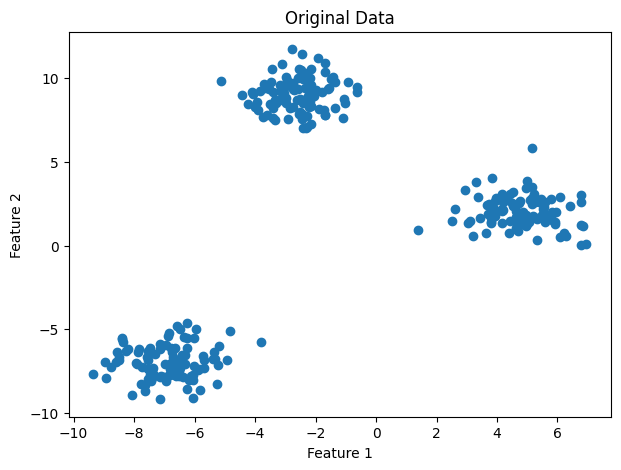

In [23]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X[:,0],
    X[:,1]
)

plt.title(
    "Original Data"
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.show()

In [24]:
gmm = GaussianMixture(
    n_components=3,
    max_iterations=100
)

gmm.fit(
    X
)

gmm_labels = gmm.labels

np.unique(
    gmm_labels,
    return_counts=True
)

(array([0, 1, 2], dtype=int64), array([100, 100, 100], dtype=int64))

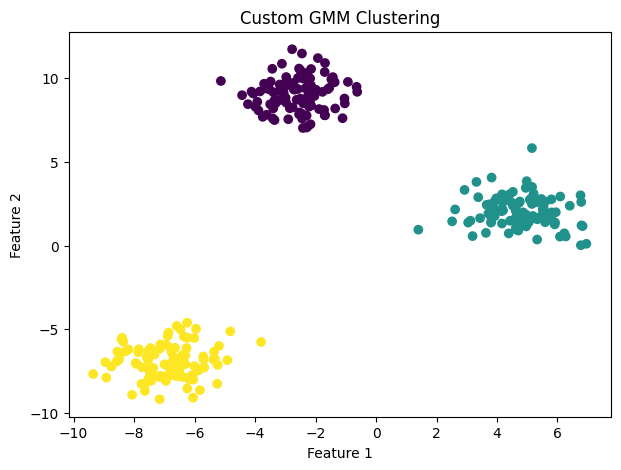

In [25]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=gmm_labels
)

plt.title(
    "Custom GMM Clustering"
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.show()

In [26]:
print(
    gmm.responsibilities[:10]
)

[[5.79506157e-67 1.35999675e-60 1.00000000e+00]
 [1.36438005e-64 3.14154567e-60 1.00000000e+00]
 [1.00000000e+00 1.72369478e-15 2.05865579e-51]
 [8.23076192e-24 1.00000000e+00 1.71564500e-45]
 [1.20447754e-71 9.85406873e-70 1.00000000e+00]
 [7.86374676e-33 1.00000000e+00 5.35909457e-46]
 [1.00000000e+00 1.28187028e-22 6.62024106e-62]
 [4.03172216e-32 1.00000000e+00 1.59110948e-42]
 [1.00000000e+00 1.71082744e-22 3.55372635e-57]
 [1.00000000e+00 4.78982670e-27 3.63941531e-62]]


In [27]:
print(
    gmm.means
)

[[-2.63323268  9.04356978]
 [ 4.74710337  2.01059427]
 [-6.88387179 -6.98398415]]


<h3> Step 3: Custom GMM vs Scikit-Learn GaussianMixture

In [28]:
sk_gmm = SKGaussianMixture(
    n_components=3,
    random_state=42
)

sk_gmm.fit(
    X
)

sk_labels = sk_gmm.predict(
    X
)

np.unique(
    sk_labels,
    return_counts=True
)

(array([0, 1, 2], dtype=int64), array([100, 100, 100], dtype=int64))

In [29]:
ari = adjusted_rand_score(
    gmm_labels,
    sk_labels
)

print(
    ari
)

1.0


In [30]:
ari_custom = adjusted_rand_score(
    y,
    gmm_labels
)


ari_sklearn = adjusted_rand_score(
    y,
    sk_labels
)


print(
    ari_custom
)

print(
    ari_sklearn
)

1.0
1.0


Analysis — Custom GMM vs. Scikit-Learn GMM
1. Cluster Distribution
Sklearn:
(array([0,1,2]), array([100,100,100]))

It is exactly the same as the Custom GMM.
This means both models:
- Identified 3 Gaussian components.
- Split the data into three equal groups.
2. ARI: Custom vs. Sklearn
Result:
ARI = 1.0
Meaning:
Custom GMM
=
Sklearn GaussianMixture

They are completely identical in terms of cluster structure.
3. ARI vs. Ground Truth
Result:
Custom GMM vs. True Labels:

1.0


Sklearn GMM vs. True Labels:

1.0

This means both models successfully identified the exact same three groups that existed when the data was generated.
Important Educational Note
This dataset represented an ideal scenario for GMM:
- Clusters are distinct.
- Each cluster is approximately Gaussian.
- There is minimal overlap.
Under such conditions:
GMM
≈
Perfect Clustering

However, with real-world data, typically:
- Gaussians overlap.
- Covariances differ.
- Cluster boundaries are not clear-cut.
And that is where GMM's main advantage—
Soft Assignment

—truly comes into play.

<h3> Step 4: GMM on Iris Dataset

In [31]:
iris = load_iris()

X = iris.data
y = iris.target

In [32]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

Custom GMM

In [33]:
iris_gmm = GaussianMixture(
    n_components=3,
    max_iterations=100
)

iris_gmm.fit(
    X_scaled
)

iris_gmm_labels = iris_gmm.labels

np.unique(
    iris_gmm_labels,
    return_counts=True
)

(array([0, 1, 2], dtype=int64), array([85, 49, 16], dtype=int64))

In [34]:
iris_gmm.means

array([[ 0.62200156, -0.34449259,  0.71443766,  0.70302395],
       [-1.0026005 ,  0.90399382, -1.30318846, -1.2562824 ],
       [-0.36597459, -1.03719388,  0.11864243,  0.02399207]])

In [35]:
iris_gmm.responsibilities[:5]

array([[2.15016274e-11, 1.00000000e+00, 6.38529706e-51],
       [6.02465558e-08, 9.99999940e-01, 2.15085617e-29],
       [3.17419797e-09, 9.99999997e-01, 6.00738443e-36],
       [6.85861985e-08, 9.99999931e-01, 1.06576740e-58],
       [7.21177213e-12, 1.00000000e+00, 1.28014929e-61]])

In [36]:
uncertainty = np.max(
    iris_gmm.responsibilities,
    axis=1
)

indices = np.argsort(
    uncertainty
)[:10]

print(
    iris_gmm.responsibilities[indices]
)

[[4.45127602e-001 3.12027499e-082 5.54872398e-001]
 [5.59661228e-001 1.13607411e-065 4.40338772e-001]
 [3.80961371e-001 7.71237250e-113 6.19038629e-001]
 [6.33731412e-001 4.38437745e-139 3.66268588e-001]
 [3.57239212e-001 2.75064577e-061 6.42760788e-001]
 [3.53771417e-001 2.56745235e-055 6.46228583e-001]
 [6.62664407e-001 4.93592663e-071 3.37335593e-001]
 [2.96123455e-001 2.75886280e-082 7.03876545e-001]
 [2.69528231e-001 1.78527559e-063 7.30471769e-001]
 [2.38839806e-001 1.56676509e-146 7.61160194e-001]]


<h3> Step 5: Custom GMM vs Scikit-Learn GaussianMixture (Iris)

In [37]:
sk_gmm = SKGaussianMixture(
    n_components=3,
    random_state=42
)

sk_gmm.fit(
    X_scaled
)

sk_labels = sk_gmm.predict(
    X_scaled
)

np.unique(
    sk_labels,
    return_counts=True
)

(array([0, 1, 2], dtype=int64), array([98, 45,  7], dtype=int64))

In [38]:
ari_custom_sklearn = adjusted_rand_score(
    iris_gmm_labels,
    sk_labels
)

print(
    ari_custom_sklearn
)

0.7618661851226992


In [39]:
ari_custom_truth = adjusted_rand_score(
    y,
    iris_gmm_labels
)

print(
    ari_custom_truth
)

0.5425559321437503


In [40]:
ari_sklearn_truth = adjusted_rand_score(
    y,
    sk_labels
)

print(
    ari_sklearn_truth
)

0.5164585360868599


In [41]:
print(
    iris_gmm.means
)

[[ 0.62200156 -0.34449259  0.71443766  0.70302395]
 [-1.0026005   0.90399382 -1.30318846 -1.2562824 ]
 [-0.36597459 -1.03719388  0.11864243  0.02399207]]


In [42]:
print(
    sk_gmm.means_
)

[[ 0.53745909 -0.39369142  0.6693573   0.64500292]
 [-0.93852253  0.98617415 -1.29410958 -1.24871335]
 [-1.53616188 -0.9148767  -1.05760659 -1.00758605]]


<h3> Step 6: Final GMM visualization

In [44]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

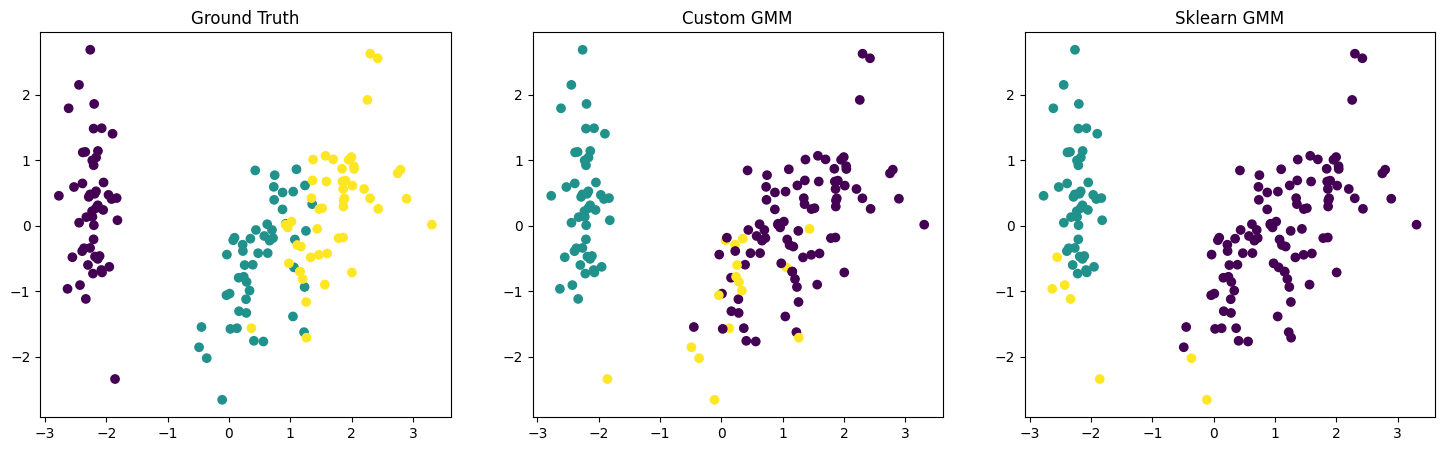

In [45]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

axes[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

axes[0].set_title(
    "Ground Truth"
)

axes[1].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=iris_gmm_labels
)

axes[1].set_title(
    "Custom GMM"
)

axes[2].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=sk_labels
)

axes[2].set_title(
    "Sklearn GMM"
)

plt.show()

### Gaussian Mixture Model (GMM)

Gaussian Mixture Model assumes that data is generated from a combination of multiple Gaussian distributions.

Unlike K-Means, which performs hard clustering, GMM performs soft clustering by assigning probabilities to each cluster.

The model was implemented using the Expectation-Maximization (EM) algorithm:

1. Initialization:
   - Random Gaussian means
   - Initial covariance matrices
   - Equal mixing weights

2. Expectation Step:
   - Calculate the probability of each sample belonging to each Gaussian component.

3. Maximization Step:
   - Update means, covariance matrices, and weights based on calculated responsibilities.

#### Iris Dataset Results

Custom GMM and Scikit-Learn GaussianMixture were evaluated using Adjusted Rand Index (ARI).

| Model | ARI |
|---|---:|
| Custom vs Sklearn GMM | 0.762 |
| Custom GMM vs Ground Truth | 0.543 |
| Sklearn GMM vs Ground Truth | 0.516 |

The results show that both implementations capture the general structure of Iris data, but the overlap between Versicolor and Virginica limits perfect clustering.

GMM provides additional information through soft assignments, where each sample receives a probability of belonging to every cluster.

### Final Comparison of Project Clustering Algorithms

| Algorithm | Main Idea | Strength | Limitation |
|-|-|-|-|
|K-Means|Centroid based|Simple and fast|Needs K, spherical clusters|
|DBSCAN|Density based|Finds noise, arbitrary shapes|Sensitive to eps|
|Hierarchical|Tree based merging|Dendrogram, no initial K|Computational cost|
|GMM|Probability based|Soft clustering, flexible shapes|Sensitive to initialization|